
# Visualização de Dados com Spotify

Nesta aula vamos praticar:
- pandas
- matplotlib
- seaborn
- análise exploratória de dados (EDA)
- visualização estatística

---

O que vamos aprender
- histogramas
- KDE
- scatter plots
- regressão
- heatmaps
- boxplots
- gráficos categóricos
- groupby
- interpretação de gráficos


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)



# Carregando a Base

In [4]:
# Baixando a última versão no kaggle
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
df = pd.read_csv(path+"/dataset.csv")
print("Path to dataset files:", path)

df.head()


Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



# Conhecendo os Dados


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000



#Histograma + KDE


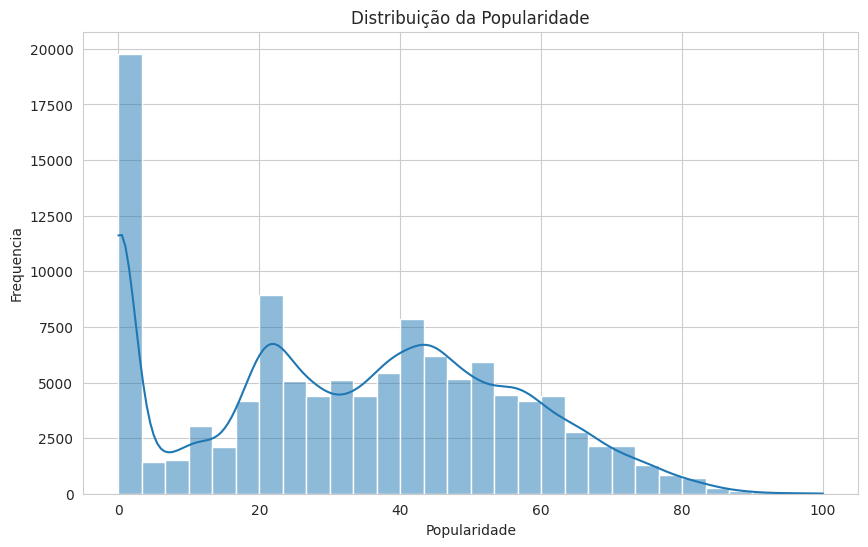

In [10]:
sns.histplot(df["popularity"], bins=30, kde=True)
plt.title("Distribuição da Popularidade")
plt.xlabel("Popularidade")
plt.ylabel("Frequencia")
plt.show()


# Scatter Plot


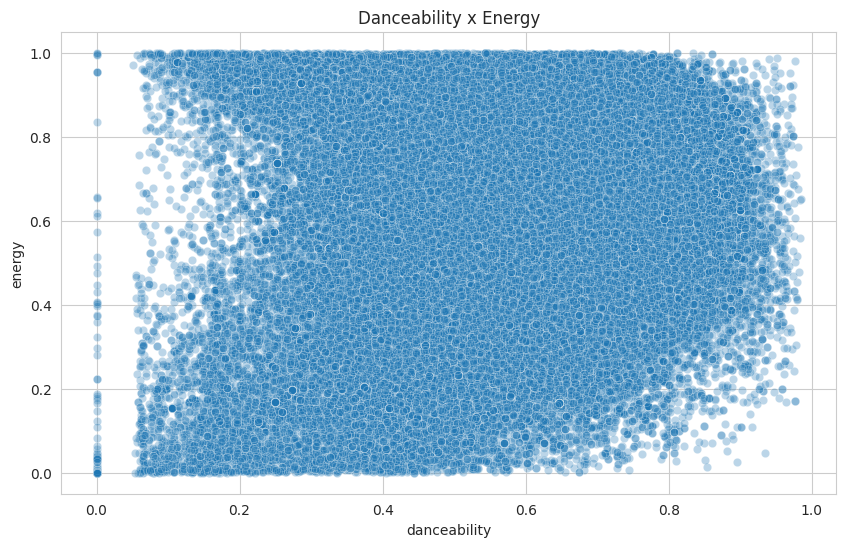

In [12]:
sns.scatterplot(data=df, x="danceability", y="energy", alpha = 0.3)
plt.title("Danceability x Energy")
plt.show()


#Correlação


In [13]:
corr = df.corr(numeric_only=True)
corr

,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Unnamed: 0,1.000000,0.032142,-0.032743,-0.054736,0.003444,-0.055994,-0.005520,-0.027307,0.005107,-0.084952,0.076840,-0.070286,0.033639,0.053111,-0.025824,-0.021115
popularity,0.032142,1.000000,-0.007101,0.044082,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.032743,-0.007101,1.000000,-0.065263,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
explicit,-0.054736,0.044082,-0.065263,1.000000,0.122507,0.096955,0.004484,0.108588,-0.037212,0.307952,-0.094403,-0.103404,0.032549,-0.003381,-0.002816,0.038386
danceability,0.003444,0.035448,-0.073426,0.122507,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,-0.055994,0.001056,0.058523,0.096955,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.005520,-0.003853,0.008114,0.004484,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,-0.027307,0.050423,-0.003470,0.108588,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,0.005107,-0.013931,-0.035556,-0.037212,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.084952,-0.044927,-0.062600,0.307952,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011


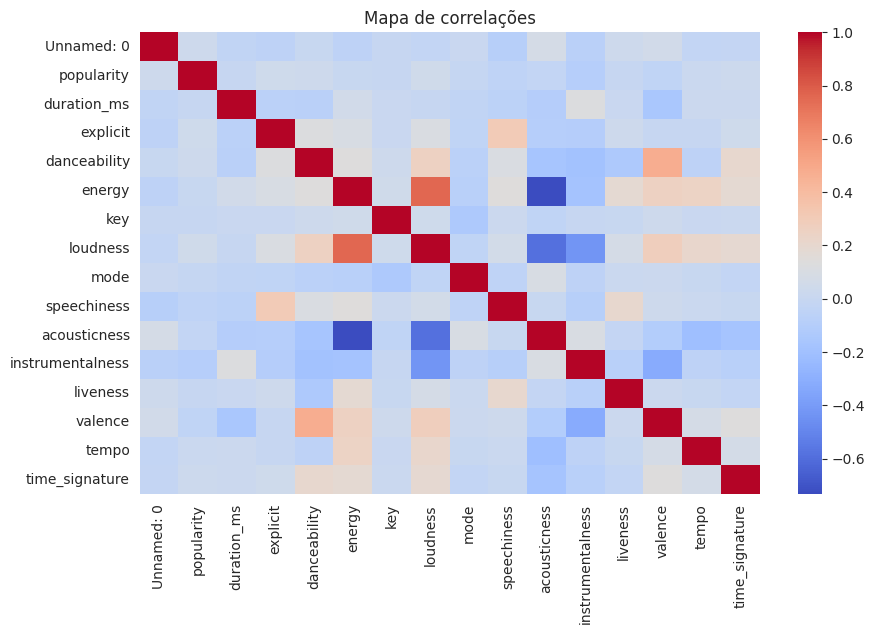

In [14]:
sns.heatmap(corr,cmap="coolwarm")
plt.title("Mapa de correlações")
plt.show()


# Boxplot


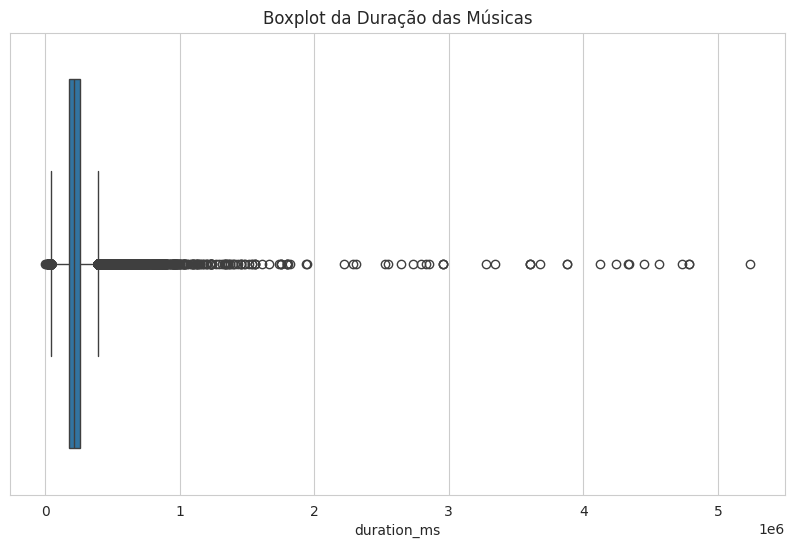

In [15]:
sns.boxplot(x=df["duration_ms"])
plt.title("Boxplot da Duração das Músicas")
plt.show()


#Top 10 Artistas


In [20]:
top_artistas = (df.groupby("artists")["popularity"].mean().sort_values(ascending=False)).head(100)
top_artistas
#top_artistas.plot.barh()


,popularity
artists,
Sam Smith;Kim Petras,100.0
Bizarrap;Quevedo,99.0
Manuel Turizo,98.0
Bad Bunny;Chencho Corleone,97.0
Bad Bunny;Bomba Estéreo,94.5
...,...
Rauw Alejandro;Chencho Corleone,83.0
El Alfa;Noriel;Trueno,82.0
Riton;Nightcrawlers;Mufasa & Hypeman;Dopamine,82.0



# EXERCÍCIOS


#O que influencia popularidade?
Descubra quais características musicais parecem mais relacionadas com popularidade. Selecione as variáveis numéricas, calcule a correlação, visualize com o heatmap e interprete.


# RESPONDA

In [1]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre Características Musicais')
plt.tight_layout()
plt.show()

corr['popularity'].drop('popularity').sort_values(ascending=False)



#Músicas felizes são mais populares?
Analise se músicas com maior valence (positividade/felicidade) tendem a ser mais populares. Crie:


*   scatter plot
*   linha de regressão (1 ponto extra)

Depois interprete o resultado.


# RESPONDA

In [1]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='valence', y='popularity', alpha=0.3, color='steelblue', label='Músicas')
sns.regplot(data=df, x='valence', y='popularity', scatter=False,
            line_kws={'color': 'red', 'linewidth': 2}, label='Regressão linear')

plt.title('Valência vs. Popularidade')
plt.xlabel('Valência')
plt.ylabel('Popularidade')
plt.legend()
plt.tight_layout()
plt.show()

print('Correlação:', df['valence'].corr(df['popularity']).round(3))



# Quais gêneros dominam o Spotify?
Descubra os gêneros mais frequentes, os gêneros com maior popularidade média e compare frequência com popularidade

Gere dois gráficos e interprete: gêneros populares são necessariamente os mais frequentes?

# RESPONDA


In [1]:
top_freq = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_freq.values, y=top_freq.index, palette='Blues_r')
plt.title('Top 10 Gêneros Mais Frequentes')
plt.xlabel('Número de músicas')
plt.ylabel('Gênero')
plt.tight_layout()
plt.show()

top_pop = (
    df.groupby('track_genre')['popularity']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_pop.values, y=top_pop.index, palette='Oranges_r')
plt.title('Top 10 Gêneros por Popularidade Média')
plt.xlabel('Popularidade média')
plt.ylabel('Gênero')
plt.tight_layout()
plt.show()

freq_rank = df['track_genre'].value_counts().rank(ascending=False).rename('rank_freq')
pop_rank  = (
    df.groupby('track_genre')['popularity']
      .mean()
      .rank(ascending=False)
      .rename('rank_pop')
)
comp = pd.concat([freq_rank, pop_rank], axis=1).dropna()
print('Correlação frequência x popularidade:', comp['rank_freq'].corr(comp['rank_pop']).round(3))



# Discussão Final

- Correlação implica causalidade?
- Existem outliers?
- KDE foi útil?
- Quais variáveis parecem mais importantes?


In [ ]:
print(corr['popularity'].drop('popularity').sort_values(ascending=False).round(3))

q1 = df['duration_ms'].quantile(0.25)
q3 = df['duration_ms'].quantile(0.75)
iqr = q3 - q1
outliers = df[(df['duration_ms'] < q1 - 1.5*iqr) | (df['duration_ms'] > q3 + 1.5*iqr)]
print(f'Outliers em duration_ms: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['popularity'], bins=30, ax=axes[0])
axes[0].set_title('Histograma')
sns.kdeplot(df['popularity'], ax=axes[1], fill=True)
axes[1].set_title('KDE')
plt.suptitle('Popularidade: Histograma vs KDE')
plt.tight_layout()
plt.show()

corr['popularity'].drop('popularity').abs().sort_values(ascending=False).head(5).round(3)


Correlação não implica causalidade. Uma música com alto `loudness` não é popular por causa do volume — ambos refletem tendências de produção em gêneros que já têm grande audiência.

Existem outliers em `duration_ms`: músicas muito curtas (interludes) ou longas (ao vivo, música clássica) ficam fora do IQR. O boxplot deixou isso evidente na cauda direita.

O KDE foi útil porque o histograma criava picos artificiais dependendo do número de bins. O KDE revelou a bimodalidade da popularidade: um pico próximo de 0 (músicas pouco ouvidas). 

`loudness`, `energy` e `danceability` têm as maiores correlações absolutas com popularidade, ainda que fracas. Popularidade é multifatorial — algoritmo, marketing e viralização não estão presentes no dataset.
